In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision

from torchvision.transforms import v2

import torchinfo

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

#torch.backends.cudnn.benchmark = True

print(device)

BASE_PATH = 'C:/Users/Rodrigo/Desktop/VCPI-2526'

PATH_TRAINING_SET = f'{BASE_PATH}/train_images'
PATH_TEST_SET = f'{BASE_PATH}/test_images'

AUG_PATH = f'{BASE_PATH}/train_augmented'

BATCH_SIZE = 32
EPOCHS = 30
RUNS = 1

cuda:0


In [3]:
def show_bad_preds(model, dataset, classes):
    k = 0
    iters = 0

    preds = []
    ground_truth = []

    imgs = torch.Tensor(52, 3, 32, 32)

    iterator = iter(dataset)

    max_iters = test_set.__len__() / BATCH_SIZE

    while k < 52 and iters < max_iters:

        try:
            images, targets = next(iterator)
        except StopIteration:
            break

        logits = model(images.to(device))

        predictions = torch.nn.functional.softmax(logits, dim=1)\
                        .cpu().detach().numpy()

        for i in range(len(predictions)):

            if np.argmax(predictions[i]) != targets[i] and k < 52:

                preds.append(predictions[i])
                ground_truth.append(targets[i])
                imgs[k, :, :, :] = images[i]
                k += 1

        iters += 1

    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 13, 4)




def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix='model'):

    history = {
        'accuracy': [],
        'val_acc': [],
        'val_loss': [],
        'loss': []
    }

    best_val_loss = np.inf

    for epoch in range(epochs):

        model.train()
        start_time = time.time()

        correct = 0
        running_loss = 0.0

        for i, (inputs, targets) in enumerate(train_loader, 0):

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        model.eval()

        with torch.no_grad():

            v_correct = 0
            val_loss = 0.0

            for i, t in val_loader:
                i = i.to(device)
                t = t.to(device)

                o = model(i)
                _, p = torch.max(o, 1)

                val_loss += loss_fn(o, t).item() * t.size(0)
                v_correct += (p == t).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)

        stop_time = time.time()

        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; '
              f'Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; '
              f'Elapsed time: {(stop_time - start_time):0.4f}')

        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['loss'].append(epoch_loss)   # FIX

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
            }, f'{save_prefix}.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break

    print('Finished Training')

    return history



def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    with torch.no_grad():
        for i, (images, targets) in enumerate(data_loader):
            
            # forward pass, compute the output of the model for the current batch
            outputs = model(images.to(device))

            # "max" returns a namedtuple (values, indices) where values is the maximum 
            # value of each row of the input tensor in the given dimension dim; 
            # indices is the index location of each maximum value found (argmax).
            # the argmax effectively provides the predicted class number        
            _, preds = torch.max(outputs, dim=1)

            correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()



class Conv_II(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # Block 1
        self.conv1 = torch.nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(32)
        self.relu1 = torch.nn.ReLU()

        self.conv2 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(64)
        self.relu2 = torch.nn.ReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)

        # Block 2
        self.conv3 = torch.nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = torch.nn.BatchNorm2d(128)
        self.relu3 = torch.nn.ReLU()

        self.conv4 = torch.nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = torch.nn.BatchNorm2d(128)
        self.relu4 = torch.nn.ReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.dropout = torch.nn.Dropout(p=0.5)

        # GAP -> 128 canais
        self.fc1 = torch.nn.Linear(128, num_classes)

    def forward(self, x):

        # input = (bs, 3, 32, 32)

        x = self.conv1(x)       # -> (bs, 32, 32, 32)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)       # -> (bs, 64, 32, 32)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.maxpool1(x)    # -> (bs, 64, 16, 16)

        x = self.conv3(x)       # -> (bs, 128, 16, 16)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)       # -> (bs, 128, 16, 16)
        x = self.bn4(x)
        x = self.relu4(x)

        x = self.maxpool2(x)    # -> (bs, 128, 8, 8)

        # Global Average Pooling
        x = torch.mean(x, dim=[2, 3])   # -> (bs, 128)

        x = self.dropout(x)

        x = self.fc1(x)

        return x

class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta
        self.counter = 0

        self.min_delta
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False

In [4]:
transform_aug = v2.Compose([

    v2.Resize((32, 32)),

    v2.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=15,
        interpolation=v2.InterpolationMode.BILINEAR
    ),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

In [5]:
dataset_original = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET
)

classes = dataset_original.classes

os.makedirs(AUG_PATH, exist_ok=True)

N_AUGS = 3

In [6]:
for class_name in classes:

    original_class_path = os.path.join(
        PATH_TRAINING_SET,
        class_name
    )

    aug_class_path = os.path.join(
        AUG_PATH,
        class_name
    )

    os.makedirs(aug_class_path, exist_ok=True)

    image_names = [

        img_name

        for img_name in os.listdir(original_class_path)

        if img_name.lower().endswith((
            '.png',
            '.jpg',
            '.jpeg',
            '.ppm'
        ))
    ]

    for img_name in image_names:

        img_path = os.path.join(
            original_class_path,
            img_name
        )

        img = Image.open(img_path).convert('RGB')

        # SAVE ORIGINAL

        img_resized = img.resize((32, 32))

        img_resized.save(

            os.path.join(
                aug_class_path,
                f'orig_{img_name}'
            )
        )

        # SAVE AUGMENTATIONS

        for k in range(N_AUGS):

            aug_img = transform_aug(img)

            aug_img_pil = torchvision.transforms.ToPILImage()(aug_img)

            aug_img_pil.save(

                os.path.join(
                    aug_class_path,
                    f'augmented_{k}_{img_name}'
                )
            )

In [7]:
transform = v2.Compose([
    v2.Resize((32, 32)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

full_train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform
)

train_size = int(0.8 * len(full_train_set))
val_size = len(full_train_set) - train_size

train_set, val_set = torch.utils.data.random_split(
    full_train_set,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_set = torchvision.datasets.ImageFolder(
    root=PATH_TEST_SET,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [8]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(full_train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'weights/static_randomAffine_aug_I_{i}')

Epoch: 000; Loss: 2.469638; Accuracy: 29.3702; Val Loss: 1.843534; Val Acc: 42.5177; Elapsed time: 24.4309
Epoch: 001; Loss: 1.342210; Accuracy: 59.5077; Val Loss: 0.973309; Val Acc: 69.4767; Elapsed time: 20.7337
Epoch: 002; Loss: 0.649588; Accuracy: 82.2754; Val Loss: 0.304105; Val Acc: 94.4696; Elapsed time: 21.0851
Epoch: 003; Loss: 0.314075; Accuracy: 92.0890; Val Loss: 0.126077; Val Acc: 98.6421; Elapsed time: 20.2319
Epoch: 004; Loss: 0.170167; Accuracy: 96.1453; Val Loss: 0.080393; Val Acc: 98.6704; Elapsed time: 20.3062
Epoch: 005; Loss: 0.116025; Accuracy: 97.3866; Val Loss: 0.122919; Val Acc: 98.0905; Elapsed time: 19.5910
Epoch: 006; Loss: 0.080307; Accuracy: 98.2636; Val Loss: 0.040742; Val Acc: 99.0523; Elapsed time: 19.6454
Epoch: 007; Loss: 0.070016; Accuracy: 98.4334; Val Loss: 0.034561; Val Acc: 99.4767; Elapsed time: 19.4786
Epoch: 008; Loss: 0.052807; Accuracy: 98.8330; Val Loss: 0.011942; Val Acc: 99.8586; Elapsed time: 19.3087
Epoch: 009; Loss: 0.046877; Accuracy:

In [9]:
res = 0
model_Conv = Conv_II(len(full_train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'weights/static_randomAffine_aug_I_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)
    res += eval

""" reload = torch.load(f'weights/static_randomAffine_aug_I_{i}.pt')
model_Conv.load_state_dict(reload['model'])
eval = evaluate(model_Conv, test_loader)
eval_val = evaluate(model_Conv, val_loader)
print(reload['epoch'], eval, eval_val)
res += eval """

res /= RUNS    
print(res)

27 0.9810767769813538 0.999858558177948
0.9810767769813538


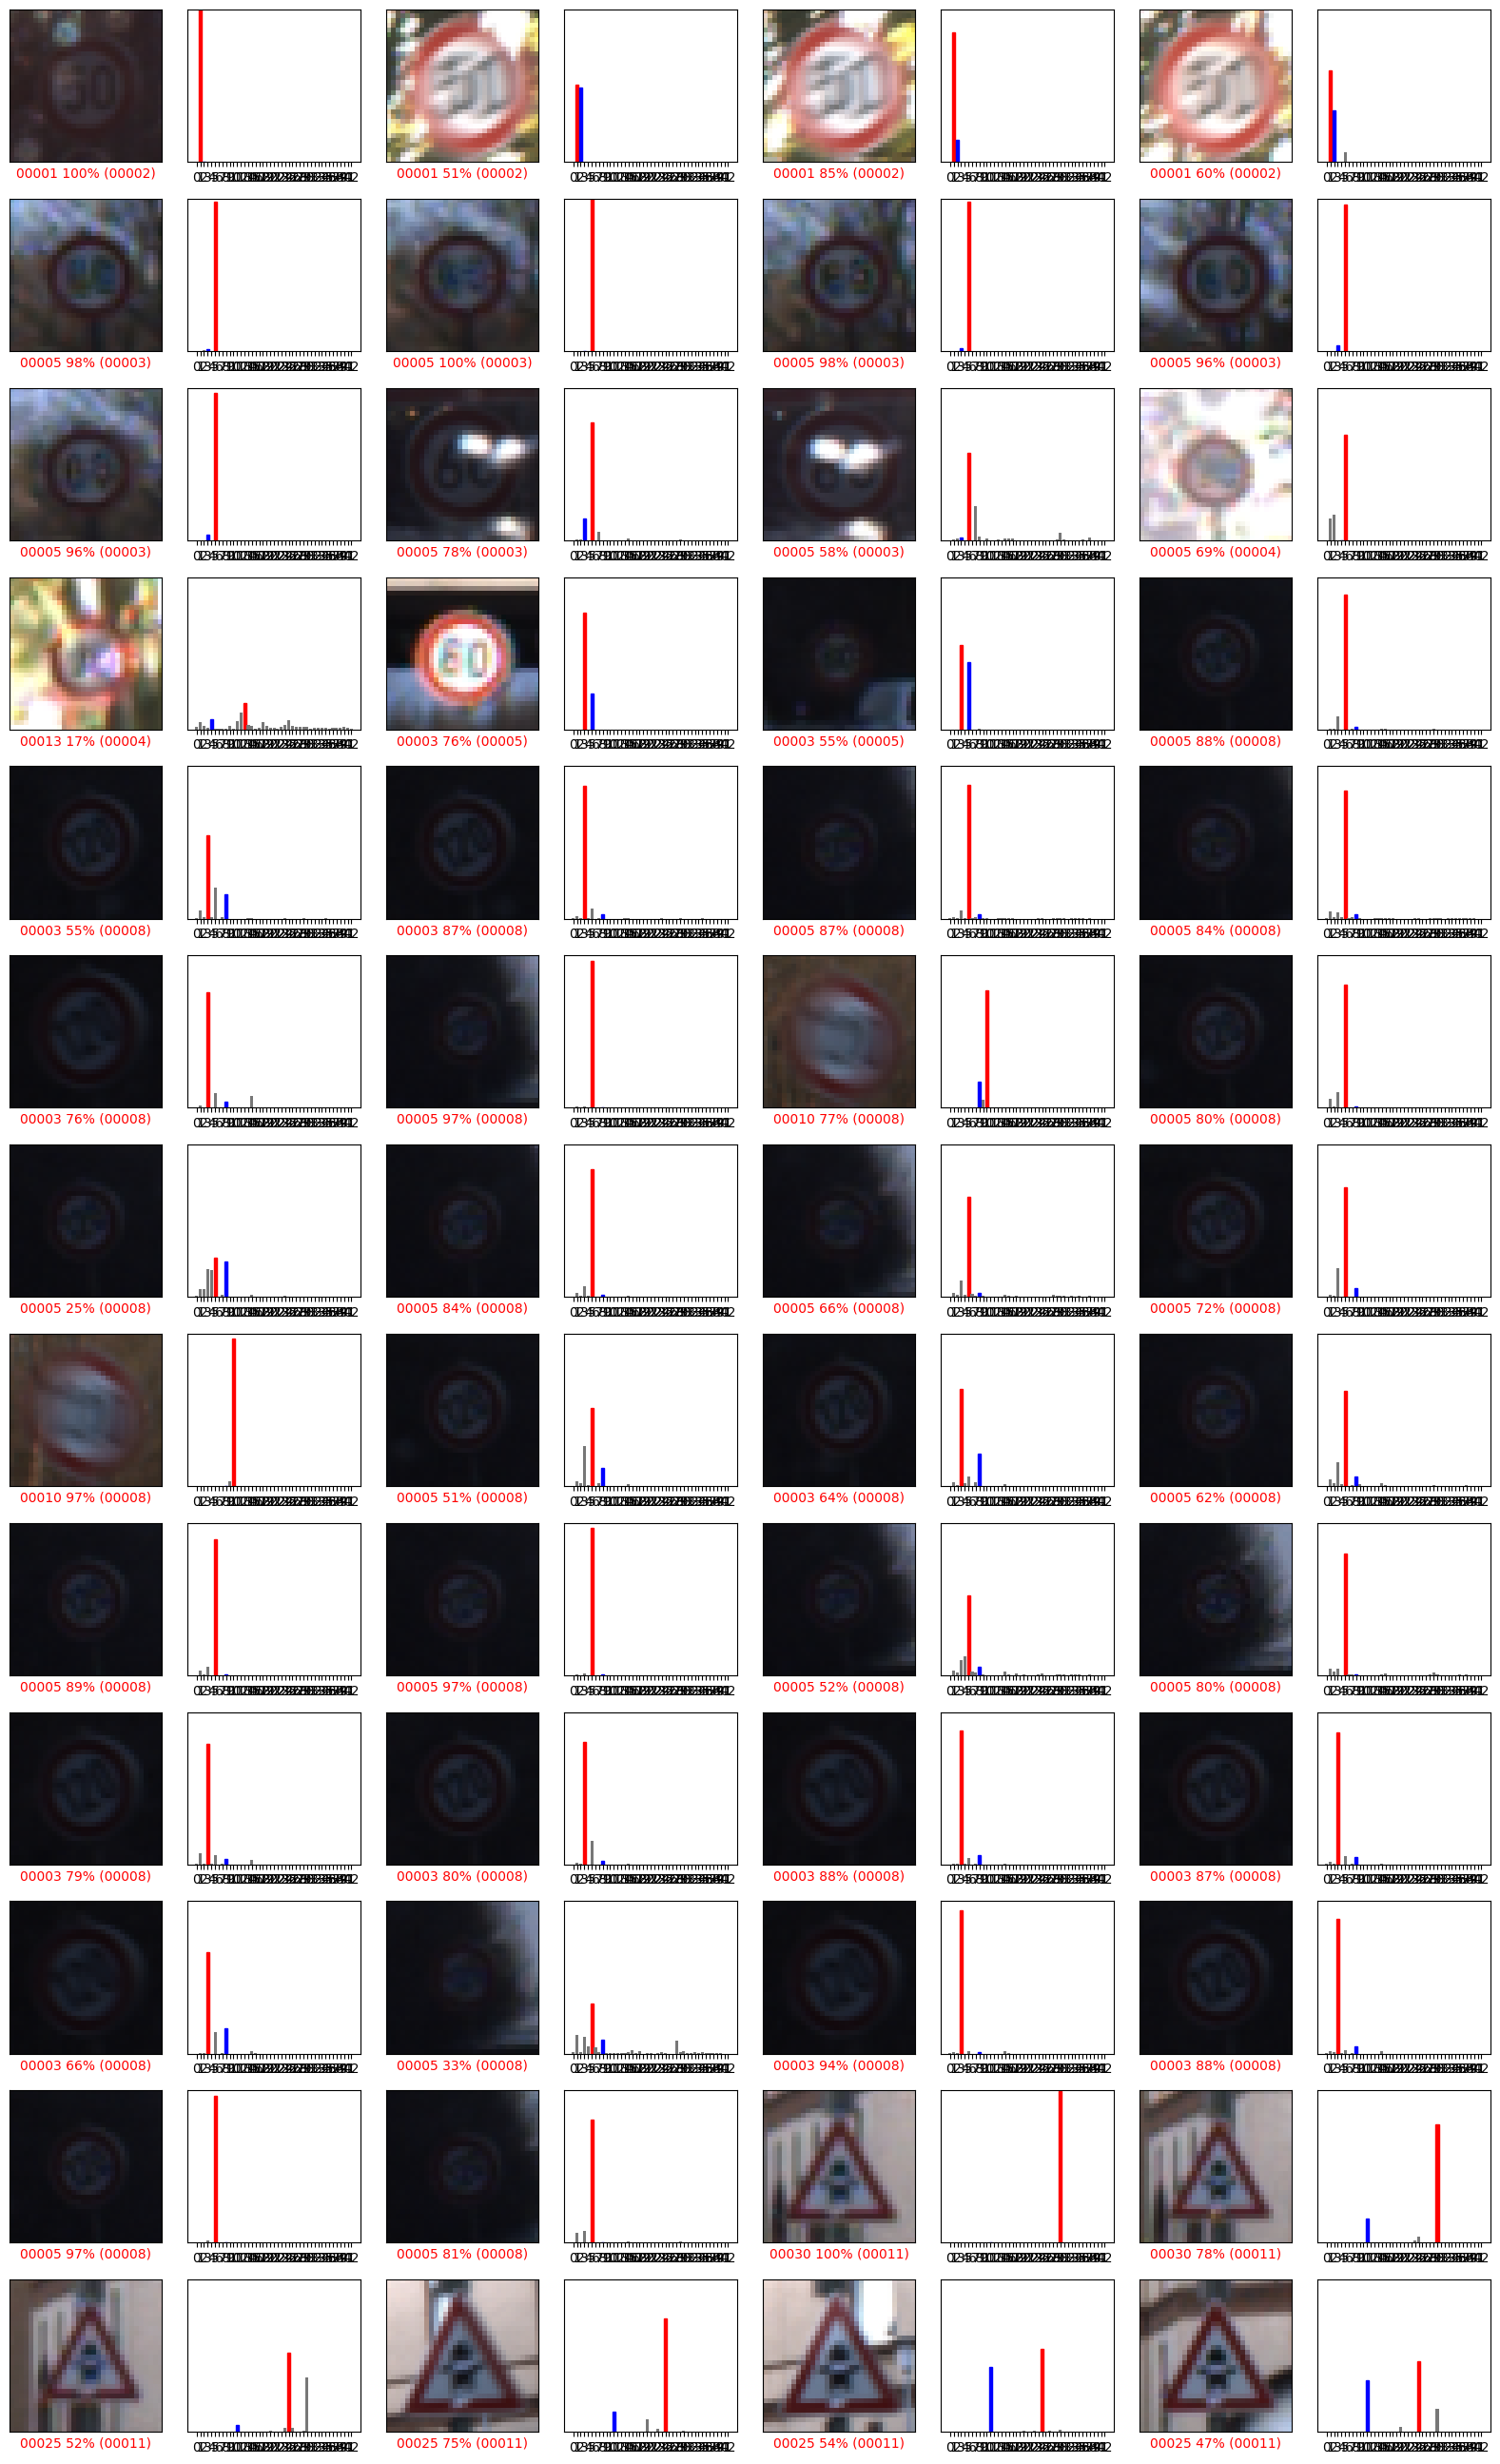

In [10]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   